# Week 6 - Production & Scaling: Wellness Agent Activity

⚠️ **WARNING: Please make save a copy of this to your own Drive. Do not make edits to this copy**

Your task: Identify scaling vulnerabilities and fix them.

## What changes in production?
- **Cost**: tokens = money → you need budgets, caps, and summaries.
- **State**: many users → you need per-user sessions and storage.
- **Reliability**: agents can loop → you need limits, validation, and logging.
- **Privacy**: health-adjacent data → minimize storage, avoid sensitive collection, and secure secrets.

As easy as it can be to jump straight into the code -- it is recommended that you take a moment and reflect on the items above about taking your agents and making them production-ready, and having a scaling infrastructure/mindset in place before you dive-in.


## Step 0: Install packages (run once)

In [ ]:
# Install packages (only need to run once)
# In a local venv, run these in your terminal instead.

!pip install -q langchain-google-genai langchain-core
!pip install -q -U google-genai


## Step 1: Set up API key

Go here to acquire your API Key or follow along: [API Key - Link](https://aistudio.google.com/app/api-keys)

In [ ]:
from google.colab import userdata

import os

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")


## Step 2: The Broken Agent

**PROBLEMS IN THIS CODE:**
- PROBLEM: Global conversation store (no user isolation)
- PROBLEM: No context cap
- PROBLEM: No token counting
- PROBLEM: No rate limiting
- PROBLEM: No logging
- PROBLEM: No error handling

**During the activity, you will fix these issues.**

In [ ]:
# BROKEN PRODUCTION AGENT - DO NOT USE IN REAL PRODUCTION
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool
from langchain_core.messages import HumanMessage, AIMessage

# LLM setup
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.4)

# Tools
@tool
def log_food(name: str, calories: float) -> str:
    """Log a food item."""
    return f"Logged {name}: {calories} cal"

@tool
def log_workout(name: str, minutes: float) -> str:
    """Log a workout."""
    return f"Logged {name}: {minutes} min"

tools = [log_food, log_workout]

# PROBLEM: Global conversation store (no user isolation)
conversation_history = []

# PROBLEM: No context cap
def chat(user_message: str):
    conversation_history.append(HumanMessage(content=user_message))

    # PROBLEM: Sends entire conversation history every time
    response = llm.invoke(conversation_history)
    conversation_history.append(response)

    # PROBLEM: No token counting
    # PROBLEM: No rate limiting
    # PROBLEM: No logging
    # PROBLEM: No error handling

    return response.content

print("Broken agent ready (pretend this serves multiple users)")


Broken agent ready (pretend this serves multiple users)


## Step 3: Test the broken agent

Run this to see the agent work, but notice all the production problems.

In [ ]:
# Test the broken agent (pretend these are different users)
print(chat("alice", "I ate a salad"))
print(chat("bob", "I went for a run"))

# Check the conversation history
print(f"\nConversation history length: {len(conversation_history)} messages")
print("NOTICE: All messages are in one global list!")
print("WARNING: If 'alice' and 'bob' both use this, they see each other's messages")

TypeError: chat() takes 1 positional argument but 2 were given

---

# Activity: Fix the Production Issues

**Your task:**

1. **Identify scaling risks** (8 min)
   - Where is money wasted?
   - Where does memory grow?
   - Where could failure occur?
   - Where would multiple users collide?

2. **Add production controls** (20 min)
   - Fix 1: Add context cap
   - Fix 2: Add user isolation (sessions dictionary)
   - Fix 3: Add token counting
   - Fix 4: Add basic rate limiting
   - Fix 5: Add logging

3. **Test multi-user isolation** (2 min)
   - Verify alice and bob have separate histories

**Work in the cells below:**

## Fix 1: Add Context Cap

Keep only the last N messages to prevent unbounded growth.

In [ ]:
# ------------------------------------------------------------
# YOUR CODE HERE: Implement context cap
# HINT: Create a function that truncates a message list to MAX_MESSAGES
# ------------------------------------------------------------

MAX_MESSAGES = 20

def cap_context(messages):
    """Keep only the last N messages."""
    # STUDENT TODO: Implement context capping logic here
    if len(messages) > MAX_MESSAGES:
        return messages[-MAX_MESSAGES:]
    return messages


print("Context cap function created")

Context cap function created


## Fix 2: Add User Isolation

Create a sessions dictionary where each user has their own message list.

In [ ]:
# ------------------------------------------------------------
# YOUR CODE HERE: Implement user isolation
# HINT: sessions = {user_id: [messages]}
# ------------------------------------------------------------

sessions = {}  # Dictionary to store per-user conversations

def get_or_create_session(user_id: str):
    """Get or create a session for this user."""
    # STUDENT TODO: Get or create a session for this user
    if user_id not in sessions:
        sessions[user_id] = []
    return sessions[user_id]


print("User isolation setup created")

User isolation setup created


## Fix 3: Add Token Counting

Estimate tokens to track cost (rough estimate: 1 token ≈ 4 characters).

In [ ]:
# ------------------------------------------------------------
# YOUR CODE HERE: Implement token counting
# HINT: 1 token ≈ 4 characters
# ------------------------------------------------------------

def estimate_tokens(messages):
    """Rough estimate: 1 token ≈ 4 characters."""
    # STUDENT TODO: Calculate total characters and divide by 4
    total_chars = sum(len(m.content) for m in messages if hasattr(m, 'content'))
    return total_chars // 4


print("Token estimation function created")

Token estimation function created


## Fix 4: Add Basic Rate Limiting

Prevent users from making too many requests per minute. If you wish to learn for a more sophisticated approaches, reference the material here:
[Rate-Limiting](https://docs.langchain.com/oss/python/langchain/models#rate-limiting)

In [ ]:
# ------------------------------------------------------------
# YOUR CODE HERE: Implement rate limiting
# HINT: Track requests per user and limit to max_per_minute
# ------------------------------------------------------------

from collections import defaultdict, deque
from time import time

request_times = defaultdict(lambda: deque(maxlen=100))

def check_rate_limit(user_id: str, max_per_minute: int = 20):
    """Check if user has exceeded rate limit."""
    # STUDENT TODO: Track request times and raise exception if limit exceeded
    now = time()
    request_times[user_id].append(now)

    # Count requests in last 60 seconds
    recent = [t for t in request_times[user_id] if now - t <= 60]

    if len(recent) > max_per_minute:

        raise Exception(f"Rate limit exceeded: {len(recent)}/{max_per_minute} per minute")

print("Rate limiting function created")

Rate limiting function created


## Fix 5: Add Logging

Log important events for debugging and monitoring.

In [ ]:
# ------------------------------------------------------------
# YOUR CODE HERE: Implement logging
# HINT: Use logging.info() to track important events
# ------------------------------------------------------------

import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger("wellness_agent")


# Use: logger.info("message here")

print("Logging setup complete")

Logging setup complete


## Fix 6: Put It All Together

Rewrite the chat() function with all fixes applied.

In [ ]:
# ------------------------------------------------------------
# YOUR FIXED CHAT FUNCTION HERE
# IMPLEMENT ALL 5 FIXES IN THIS FUNCTION
# ------------------------------------------------------------

def chat(user_id: str, user_message: str):
    """
    Fixed version with:
    - Rate limiting
    - User isolation
    - Context cap
    - Token counting
    - Logging
    """
    try:
        # Fix 4: Check rate limit (CALL check_rate_limit HERE)
        check_rate_limit(user_id)

        # Fix 2: Get user's session (CALL get_or_create_session HERE)
        messages = get_or_create_session(user_id)

        # Add new message to conversation
        messages.append(HumanMessage(content=user_message))

        # Fix 1: Cap context (CALL cap_context HERE)
        messages = cap_context(messages)

        # Fix 3: Log token count (CALL estimate_tokens and logger.info HERE)
        token_count = estimate_tokens(messages)
        logger.info(f"user={user_id}, tokens={token_count}, msg='{user_message[:30]}...'")

        # Get response
        response = llm.invoke(messages)
        messages.append(response)

        # Update session
        sessions[user_id] = messages

        return response.content

    except Exception as e:
        # Fix 5: Log errors (CALL logger.error HERE)
        logger.error(f"Error for user={user_id}: {str(e)}")
        return f"Error: {str(e)}"


print("Fixed chat function ready!")

Fixed chat function ready!


## Step 4: Test Multi-User Isolation

Verify Alice and Bob have separate conversation histories.

In [ ]:
# Test with 3 different users
print("Alice:", chat("alice", "I ate a salad"))
print("\nBob:", chat("bob", "I went for a run"))
print("\nAlice:", chat("alice", "What did I eat?"))  # Should only see Alice's data
print("\nBob:", chat("bob", "What did I do?"))      # Should only see Bob's data

print("\n" + "="*60)
print("SUCCESS: If this works, Alice and Bob have separate histories!")
print("="*60)

# Check session isolation
print(f"\nAlice's session has {len(sessions.get('alice', []))} messages")
print(f"Bob's session has {len(sessions.get('bob', []))} messages")


Alice: Got it! You ate a salad.

Bob: Got it! You went for a run.

Sounds like you're consistently getting out there! How was this particular run for you?

Alice: You ate a salad.

Bob: You went for a run!

SUCCESS: If this works, Alice and Bob have separate histories!

Alice's session has 10 messages
Bob's session has 10 messages


## Step 5: Peer Discussion

**Talk with the peers around you:**

1. Which of the 5 fixes did you implement?
2. Why is each one relevant to production systems?
3. Which fix do you believe prevents the biggest failure and why?

**Discussion points:**
- **Context cap**: Prevents quadratic cost growth
- **User isolation**: Prevents data leaks between users
- **Token counting**: Enables cost monitoring and budgeting
- **Rate limiting**: Prevents abuse and runaway costs
- **Logging**: Enables debugging and observability


---

# Extra: Cost Simulation (Optional)

Run this simulation to see why context caps matter.

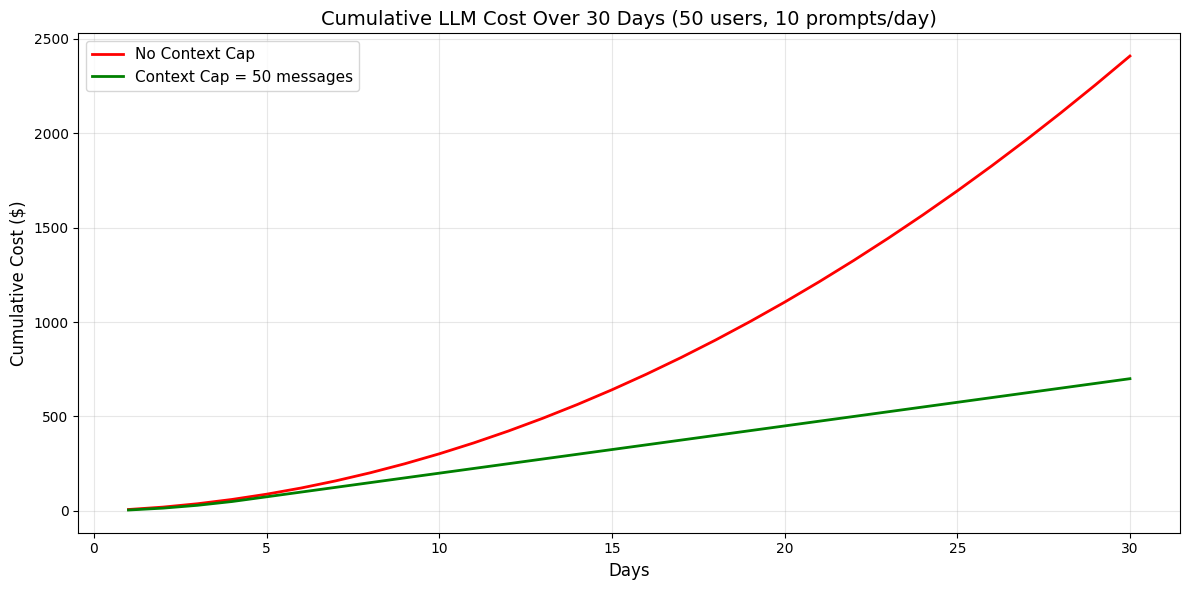


Final Cost Comparison (after 30 days):
No Context Cap:        $2407.50
With Cap (50 msg):     $700.00
Savings:               $1707.50 (70.9%)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
num_users = 50
days = 30
prompts_per_day_per_user = 10
base_cost_per_1k_tokens = 0.002
avg_tokens_per_message = 500

# Scenario 1: No context cap (context grows forever)
def simulate_no_cap(num_users, days, prompts_per_day):
    daily_costs = []
    cumulative_cost = 0

    for day in range(days):
        day_cost = 0
        for user in range(num_users):
            context_size = day * prompts_per_day + prompts_per_day

            for prompt_num in range(1, prompts_per_day + 1):
                current_context = context_size + prompt_num
                tokens = current_context * avg_tokens_per_message
                cost = (tokens / 1000) * base_cost_per_1k_tokens
                day_cost += cost

        cumulative_cost += day_cost
        daily_costs.append(cumulative_cost)

    return daily_costs

# Scenario 2: Context cap at 50 messages
def simulate_with_cap(num_users, days, prompts_per_day, cap=50):
    daily_costs = []
    cumulative_cost = 0

    for day in range(days):
        day_cost = 0
        for user in range(num_users):
            context_size = min(cap, day * prompts_per_day + prompts_per_day)

            for prompt_num in range(prompts_per_day):
                tokens = context_size * avg_tokens_per_message
                cost = (tokens / 1000) * base_cost_per_1k_tokens
                day_cost += cost

        cumulative_cost += day_cost
        daily_costs.append(cumulative_cost)

    return daily_costs

# Run simulations
no_cap_costs = simulate_no_cap(num_users, days, prompts_per_day_per_user)
capped_costs = simulate_with_cap(num_users, days, prompts_per_day_per_user, cap=50)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(range(1, days + 1), no_cap_costs, label='No Context Cap', linewidth=2, color='red')
plt.plot(range(1, days + 1), capped_costs, label='Context Cap = 50 messages', linewidth=2, color='green')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Cumulative Cost ($)', fontsize=12)
plt.title(f'Cumulative LLM Cost Over {days} Days ({num_users} users, {prompts_per_day_per_user} prompts/day)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final costs
print(f"\n{'='*60}")
print(f"Final Cost Comparison (after {days} days):")
print(f"{'='*60}")
print(f"No Context Cap:        ${no_cap_costs[-1]:.2f}")
print(f"With Cap (50 msg):     ${capped_costs[-1]:.2f}")
print(f"Savings:               ${no_cap_costs[-1] - capped_costs[-1]:.2f} ({((no_cap_costs[-1] - capped_costs[-1]) / no_cap_costs[-1] * 100):.1f}%)")
print(f"{'='*60}\n")


## Key Takeaway

**Without a context cap:**
- Cost grows as p(p+1)/2 where p = number of prompts
- This is **quadratic growth** - unsustainable!

**With a context cap:**
- Cost grows linearly
- Predictable and manageable at scale

**This is why Fix #1 (context cap) is mandatory in production!**
